# Quack — an on-device AI tutor that teaches kids Mandarin 🦆

> A fully offline, privacy-first iOS app where a secret-agent duck named **Q**
> sends children on "missions" to learn Mandarin — powered end-to-end by
> **Gemma** running on the phone.

## ✨ TL;DR

**Quack** turns learning Mandarin into a spy game for young children. Kids point
their camera at real objects, say words out loud, hear stories, and play
matching games — and a duck mascot grades them in real time. Every bit of the
intelligence — recognising what's in a photo, transcribing a spoken word,
judging pronunciation **and tone**, writing a fresh story — runs **on-device**
with Gemma via Google's LiteRT-LM runtime. **No account, no network, no data
ever leaves the phone.**

For a children's app, that last point isn't a nice-to-have — it's the whole
reason this is possible.

## 🎯 The problem

Language apps for kids have an uncomfortable trade-off:

1. **The good ones are cloud-powered.** Real speech scoring and image
   recognition usually mean streaming a child's voice and camera to a server.
   For a 5-year-old, that's a privacy minefield (COPPA, GDPR-K) and a hard sell
   to parents.
2. **The private ones are dumb.** Apps that stay on-device fall back to
   tap-the-matching-card quizzes. They can't *listen* to a child or *look* at
   what the child is holding.
3. **Almost none of them teach tone.** Mandarin is tonal — `mā` (mother) and
   `mǎ` (horse) are different words. Most kid apps quietly ignore tone, which
   means kids practise the wrong thing from day one.

We wanted an app that could genuinely see, hear, and grade a child — *without*
the cloud, and that took **tone seriously**.

Gemma's multimodality made all of it possible at once.

## 🦆 What Quack does

Quack is built around **four mission types**, launched from a duck mascot, "Q",
who frames every lesson as a secret-agent mission:

| Mission | What the child does | AI behind it |
|---|---|---|
| **Scan it** 📸 | Points the camera at a real apple / cat / cup | Gemma **vision** names the object and checks it against the target word |
| **Say it** 🎤 | Says the Mandarin word out loud | Gemma **audio** transcribes it to pinyin; Quack scores **syllables *and* tone** |
| **Story time** 📖 | Reads a short story, then a quick quiz | Gemma **text** generation writes a fresh 3-line story every time |
| **Match it** 🧩 | Matches hanzi to pictures | Pure-Swift logic game — instant and private, by design |

Three of the four missions each exercise a **different Gemma modality** —
vision, audio, and text — from **one** model file. The write-up below walks
through all three.

Around the missions sits a full kid-friendly app: a **Home** hub, a **Missions**
board, a **Library** of collectible holographic stickers earned as rewards, and
a **Parent** dashboard.

`20` vocabulary words span five themes a young child cares about — *animals,
family, food, fruits, household*.

## 📱 Screenshots

> _Captured on iPhone 15 Pro — running fully offline._

| Meet Agent Q | How it works | Home hub |
|:--:|:--:|:--:|
| 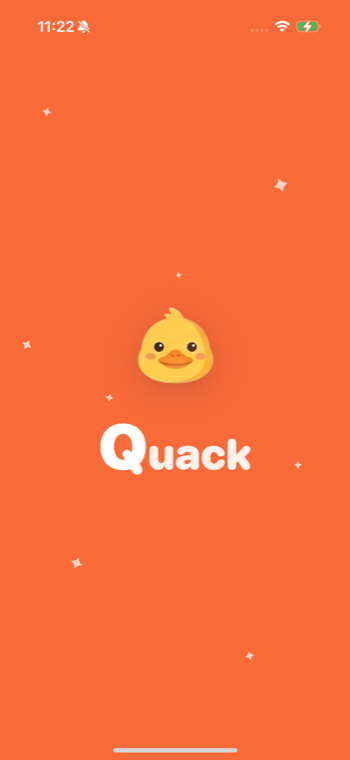 | 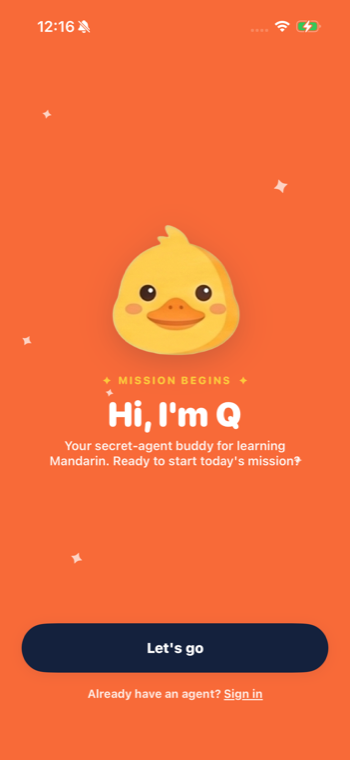 | 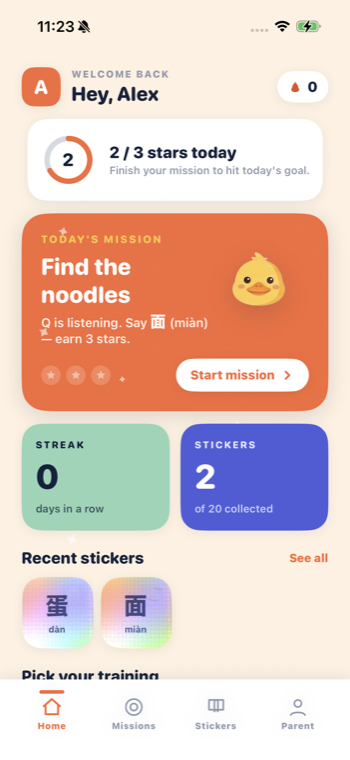 |

| Mission board | Scan it — on-device vision | Sticker library |
|:--:|:--:|:--:|
| 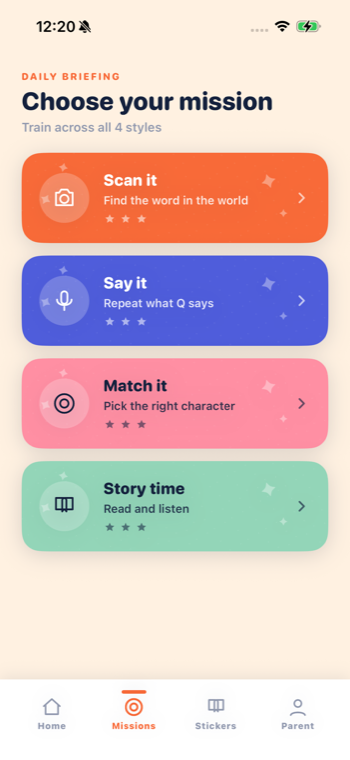 | 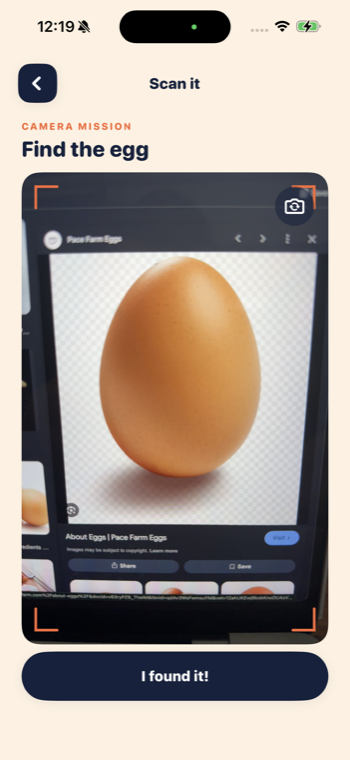 | 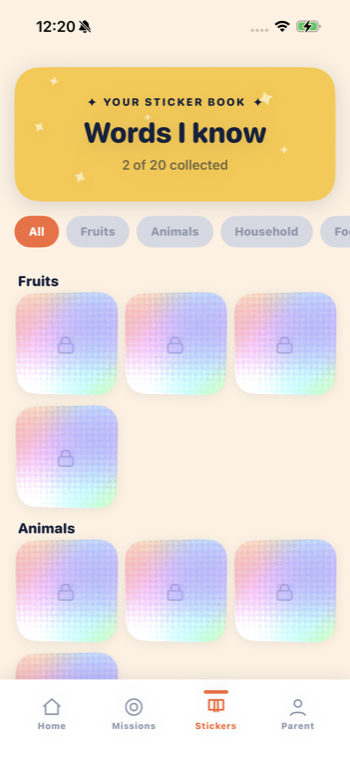 |

| Say it — recording | Say it — tone score | Parent dashboard |
|:--:|:--:|:--:|
| 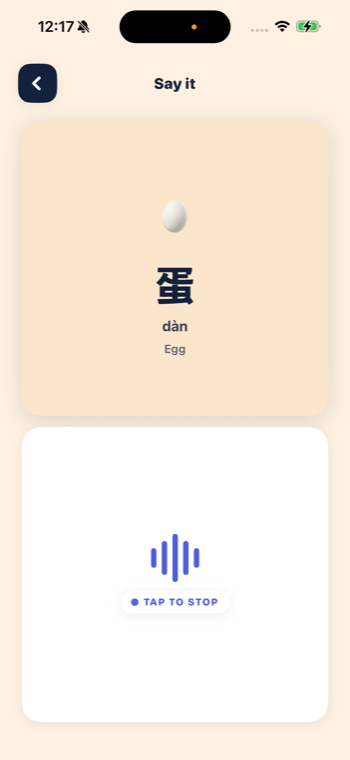 | 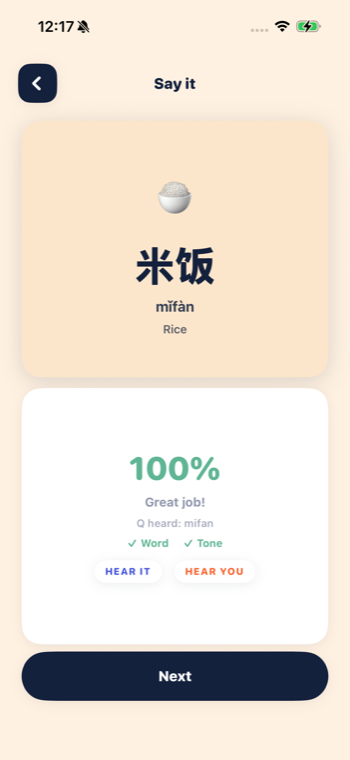 | 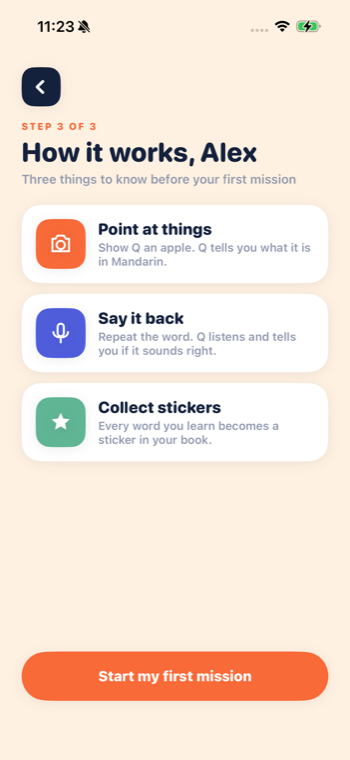 |

| Match it | Story time — Gemma-written | Mission complete 🎉 |
|:--:|:--:|:--:|
| 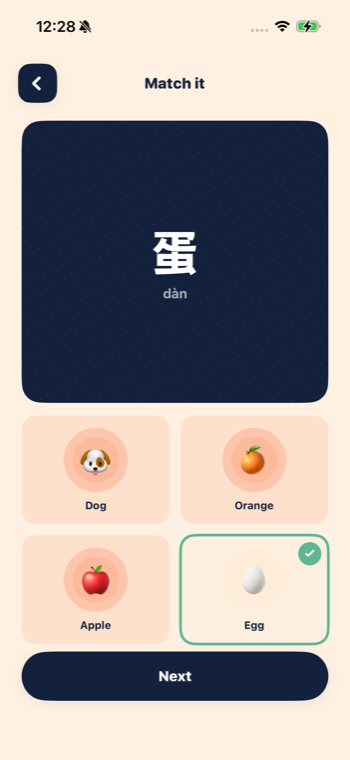 | 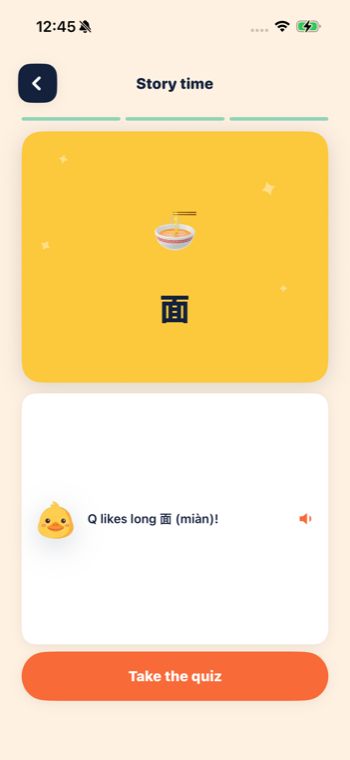 | 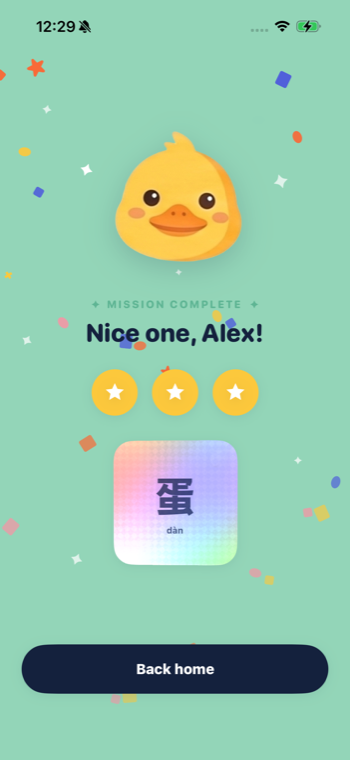 |

## 🔍 How the Gemma missions work

Each of the three AI missions uses a **different modality** of the same model.

### "Scan it" — on-device **vision**

1. A live `AVCaptureSession` shows the camera feed (front **or** back — the
   child can flip it to point at objects across the room).
2. On "I found it!", Quack captures a single still, downscales it to 768 px,
   and JPEG-encodes it.
3. The image is handed to Gemma with an open-ended prompt — *"What is the
   main object in this photo?"* — deliberately **without** revealing the target
   word, so the model can't just agree with us.
4. Swift fuzzy-matches Gemma's answer against the target English word
   (tolerant of plurals and near-spellings, strict on word boundaries so
   "egg" ≠ "eggplant").

> 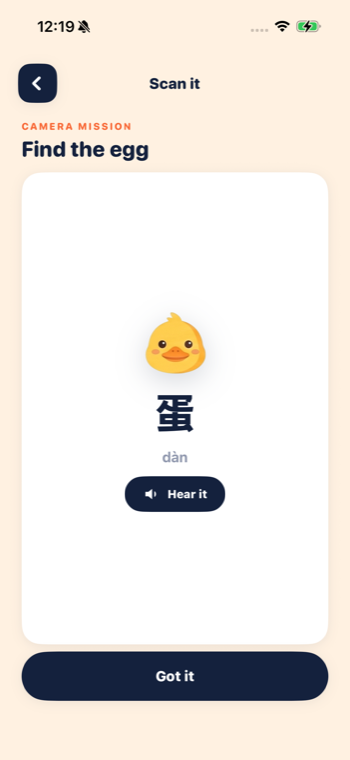
>
> _Gemma recognised the egg — Q reveals the word 蛋 (dàn)._

### "Say it" — on-device **audio** (speech *and tone*)

This is the mission we're proudest of.

1. The mic records 16 kHz mono PCM, wrapped as a WAV.
2. Gemma's **audio** modality transcribes the child's speech into **numbered
   pinyin** — e.g. `mao1`, `mi3fan4` — where the digit encodes the tone.
3. Quack scores it with a **blended, encouraging** rubric:
   - **Syllable similarity** (Levenshtein on toneless pinyin) carries 65% of
     the score.
   - **Tone correctness** carries the top 35%.
   - So the *right word with the wrong tone* lands around **65%** — a clear
     "you're close!" — and only a correct syllable **and** tone earns 100%.
4. The result screen shows two ticks — **Word ✓ / Tone ✗** — and an
   encouraging hint: *"Right word — try the falling tone!"*

A child can no longer get full marks by ignoring tone. That's the point.

| Correct word **and** tone | A missed attempt |
|:--:|:--:|
| 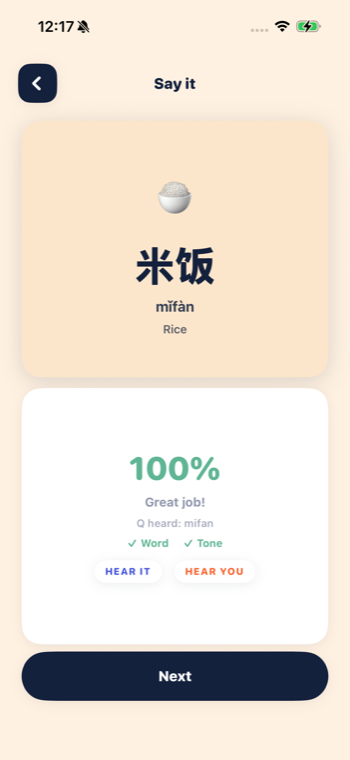 | 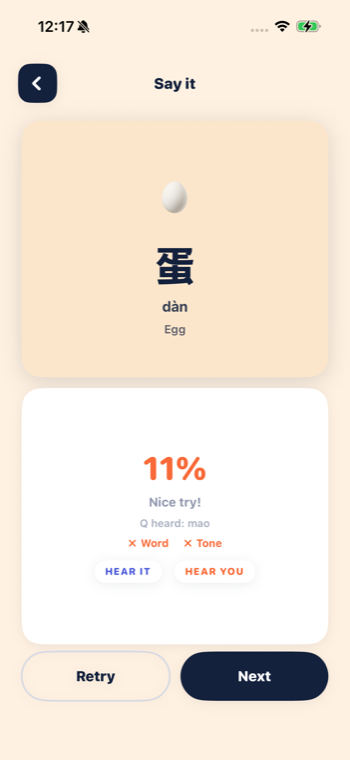 |
| `mǐfàn` → Gemma heard `mifan` — Word ✓ Tone ✓ → **100%** | Word ✗ Tone ✗ — the score stays honest |

> Sampling is pinned to greedy decoding (`topK = 1`) so the same recording
> always produces the same score — important when a kid retries a word.

### "Story time" — on-device **text generation**

1. When the mission opens, Quack picks the day's three vocab words and asks
   Gemma to write a tiny **3-line story** — one line per word, in the cheerful
   voice of Q the duck.
2. A *"Q is writing today's story…"* screen shows while the model generates,
   entirely on-device.
3. Each generated line becomes a story page; a quick picture quiz then checks
   the child understood.
4. Because the story is written **fresh every time**, no two playthroughs read
   the same — and it costs nothing and works offline. If generation ever fails,
   Quack falls back to a built-in template, so the mission never breaks.

| Q writes the story… | …and the story appears |
|:--:|:--:|
| 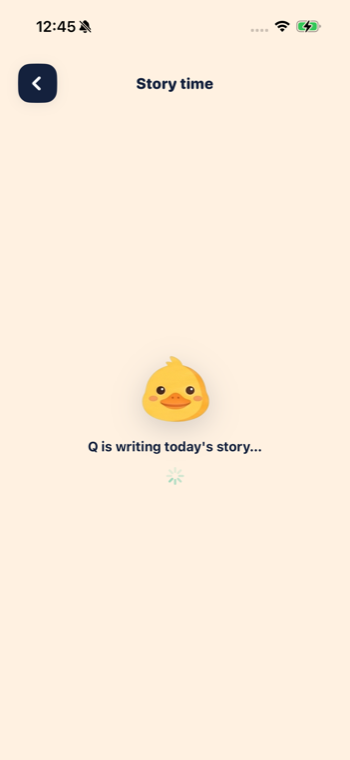 | 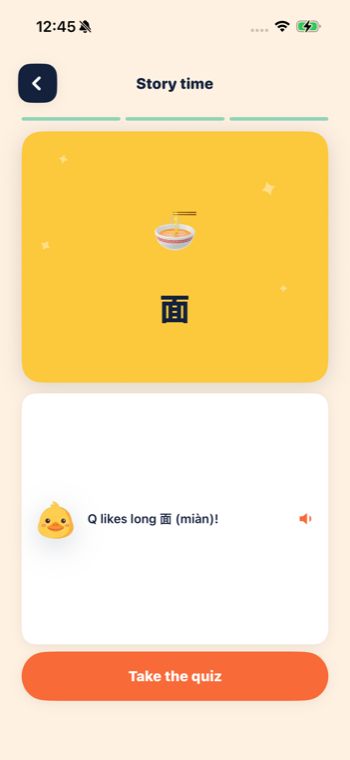 |

> Unlike the scoring missions, Story time uses normal (non-greedy) sampling —
> a story *should* vary between runs.

**Match it** rounds out the set as a pure-Swift logic game — deliberately *not*
AI. It's instant, fully private, and gives the child a fast, low-pressure way
to drill recognition between the heavier Gemma missions.

## 🏗️ Architecture

```
┌──────────────────────────────────────────────┐
│  SwiftUI app (iOS 18, @Observable AppState)   │
│  Home · Missions · Library · Parent           │
└───────────────┬──────────────────────────────┘
                │
        ┌───────▼─────────┐     ┌──────────────────┐
        │  QuackGemma     │     │  AVFoundation     │
        │  (inference     │◄────┤  Camera + Mic     │
        │   service)      │     │  capture          │
        └───────┬─────────┘     └──────────────────┘
                │  import LiteRTLM
        ┌───────▼──────────────────────────────────┐
        │  LiteRT-LM  (official Swift Package)      │
        │  Engine · Conversation · Message          │
        └───────┬───────────────────────────────────┘
                │
        ┌───────▼───────────────────────────────────┐
        │  Gemma E2B · gemma-4-E2B-it (.litertlm)    │
        │  text + vision + audio · CPU · ~2.4 GB     │
        │  bundled in the app — 100% offline         │
        └────────────────────────────────────────────┘
```

**Tech stack**

- **UI:** SwiftUI, the modern Observation framework (`@Observable`, single
  source of truth), custom Metal shaders for foil/holographic sticker effects.
- **Capture:** AVFoundation — `AVCaptureSession` for the camera (with a
  `RotationCoordinator` keeping photos horizon-level), a custom 16 kHz mic
  recorder.
- **Inference:** Google's **LiteRT-LM** official Swift Package — a single
  `import LiteRTLM`, an `Engine` actor, a fresh `Conversation` per mission.
- **Model:** **Gemma E2B** — `gemma-4-E2B-it`, the LiteRT-LM build published at
  [litert-community/gemma-4-E2B-it-litert-lm](https://huggingface.co/litert-community/gemma-4-E2B-it-litert-lm)
  on Hugging Face. Instruction-tuned and multimodal (text + vision + audio),
  bundled in the app as a single `.litertlm` file (~2.4 GB) and run on the CPU
  backend.

A single `QuackGemma` service owns the model: it loads once at launch, stays
warm, and spins up a clean `Conversation` for each mission so no turn history
leaks between a camera scan, a speech attempt, and a story.

## 🔒 Why on-device matters here

This app is *for children*. Running Gemma on-device isn't a performance
footnote — it's what makes the product defensible:

- **Privacy.** A child's face, voice, and bedroom never leave the device.
  There is no account, no server, no analytics pipeline to audit.
- **Offline.** It works on a plane, in a car, in a classroom with no Wi-Fi.
- **No running cost.** No per-inference cloud bill means the missions —
  including freshly-written stories — can be unlimited and free.
- **Latency.** Scoring happens in the moment the child is still paying
  attention.

## 🧗 Challenges we hit (and solved)

- **E4B vs E2B.** We first targeted the larger **E4B** model for accuracy. It
  runs — multimodal vision *and* audio — on an iPhone 15 Pro, but only after we
  discovered its prefill tensor arena exceeds the default iOS per-app memory
  budget (it failed with `XNNPack: Failed to allocate tensors`). The fix was
  the **Increased Memory Limit** entitlement. Even so, E4B on CPU was too slow
  for an impatient 5-year-old, so we ship **E2B** — responsive, still fully
  multimodal.
- **Small models love to agree.** Early prompts that included the target word
  made the model just say "yes". The vision and audio missions now hide the
  answer and ask open-ended questions, with the matching done in Swift.
- **Teaching tone without crushing kids.** A naive tone check ("wrong tone =
  wrong word") is accurate but brutal for beginners. The blended 65/35 score
  keeps it honest *and* encouraging.
- **Integration.** Migrating from a hand-rolled C++ bridge to LiteRT-LM's
  official Swift Package made the inference layer dramatically simpler — and
  is what let us run Gemma's larger multimodal graphs at all.

## 🏆 What we're proud of

- A children's app that genuinely **sees, hears, and tells stories** — with
  **zero** cloud dependency.
- **Tone-aware** pronunciation scoring — rare even in paid Mandarin apps.
- One model, **three modalities** (vision, audio, text), one `.litertlm` file —
  each powering a real mission.
- It runs, today, on a real iPhone.

## 🔭 What's next

- Stream the generated story token-by-token so it appears as Q "writes" it.
- Per-syllable tone feedback for multi-syllable words.
- GPU backend so E4B's higher accuracy becomes fast enough to ship.
- More vocabulary themes and a longer mission campaign.

## 🛠️ Build notes

- **Platform:** iOS 18+, Xcode 16, a physical device (the camera and
  microphone missions need real hardware).
- **Model:** `gemma-4-E2B-it.litertlm` — from
  [litert-community/gemma-4-E2B-it-litert-lm](https://huggingface.co/litert-community/gemma-4-E2B-it-litert-lm)
  on Hugging Face — bundled in the app.
- **Runtime:** LiteRT-LM, added as a local Swift Package; `CLiteRTLM.xcframework`
  plus `libGemmaModelConstraintProvider.dylib` embedded in the app.
- **Entitlement:** `com.apple.developer.kernel.increased-memory-limit`.

*Built with SwiftUI and Gemma. No servers were used in the making of this app.*